In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from utils import bADM, SAMPLING_FREQUENCY, REFRACTORY_PERIOD_DURATION

In [4]:
MAT_PATH = "smarthand_dataset.mat"           # Path to your .mat file
THRESHOLD = 0.01                             # ADM threshold (normalized units)
TAXEL_IDX = 250                        # Which taxel to plot (0–1023)
NUM_FRAMES = 100                             # How many consecutive frames to show
START_SAMPLE = 1000                           # Start from this row (time point) in tactile_data
                                             # (choose a region with dynamics, e.g. grasp)

In [5]:
data = sio.loadmat(MAT_PATH)

tactile_raw     = data['tactile_data'].astype(np.float32)      # shape: (num_frames_total, 1024)
valid_flag      = data['valid_flag'].flatten().astype(bool)
thresholds_raw  = data['threshold'].flatten().astype(np.float32)

# Normalize (as in your preprocessing)
tactile_norm = np.clip((tactile_raw - 1500) / (2700 - 1500), 0.0, 1.0)
baseline_norm = np.clip((thresholds_raw - 1500) / (1800 - 1500), 0.0, 1.0)
print(tactile_norm.shape)
# Filter to valid frames only
valid_tactile = tactile_norm[valid_flag, :]          # (num_valid_frames, 1024)
valid_baselines = baseline_norm                      # baselines are per-taxel, same for all time

# Extract time series for the chosen taxel over consecutive frames
start = START_SAMPLE
end = min(start + NUM_FRAMES, valid_tactile.shape[0])
pressure_raw = valid_tactile[start:end, TAXEL_IDX]   # shape: (NUM_FRAMES,)
baseline = valid_baselines[TAXEL_IDX]
print(pressure_raw.min(), pressure_raw.max())
# Center the signal
pressure = pressure_raw - baseline                   # shape: (NUM_FRAMES,)

# Time axis in milliseconds
t_ms = np.arange(len(pressure)) * 10.0               # 0, 10, 20, ..., (NUM_FRAMES-1)*10 ms

print(f"Selected taxel {TAXEL_IDX} over {len(pressure)} frames (starting at sample {start})")
print(f"Pressure range: [{pressure.min():.3f}, {pressure.max():.3f}] (centered)")

(339989, 1024)
0.0033333334 0.046666667
Selected taxel 250 over 100 frames (starting at sample 1000)
Pressure range: [-0.317, -0.273] (centered)


In [6]:
spike_times_up_sec, spike_times_dn_sec = bADM(
    pressure,
    threshold_UP=THRESHOLD,
    threshold_DOWN=THRESHOLD,
    sampling_frequency=SAMPLING_FREQUENCY,          # 100 Hz
    refractory_period_duration=REFRACTORY_PERIOD_DURATION,
    return_signal=False
)

# Convert spike times (seconds) to frame indices
spike_frames_up = np.round(spike_times_up_sec * SAMPLING_FREQUENCY).astype(int)
spike_frames_dn = np.round(spike_times_dn_sec * SAMPLING_FREQUENCY).astype(int)

# Clip to valid range [0, NUM_FRAMES-1]
spike_frames_up = spike_frames_up[(spike_frames_up >= 0) & (spike_frames_up < NUM_FRAMES)]
spike_frames_dn = spike_frames_dn[(spike_frames_dn >= 0) & (spike_frames_dn < NUM_FRAMES)]

print(f"UP spikes at frames: {spike_frames_up}")
print(f"DOWN spikes at frames: {spike_frames_dn}")

UP spikes at frames: [16 46 92 98]
DOWN spikes at frames: [13 27 58 81]


In [7]:
modulation = np.zeros(NUM_FRAMES)
modulation[spike_frames_up] = +THRESHOLD
modulation[spike_frames_dn] = -THRESHOLD

cumulative = np.cumsum(modulation)                   # starts at 0, steps ±θ

# Optional: start reconstruction from first pressure value
reconstruction = np.cumsum(modulation) + pressure[0]

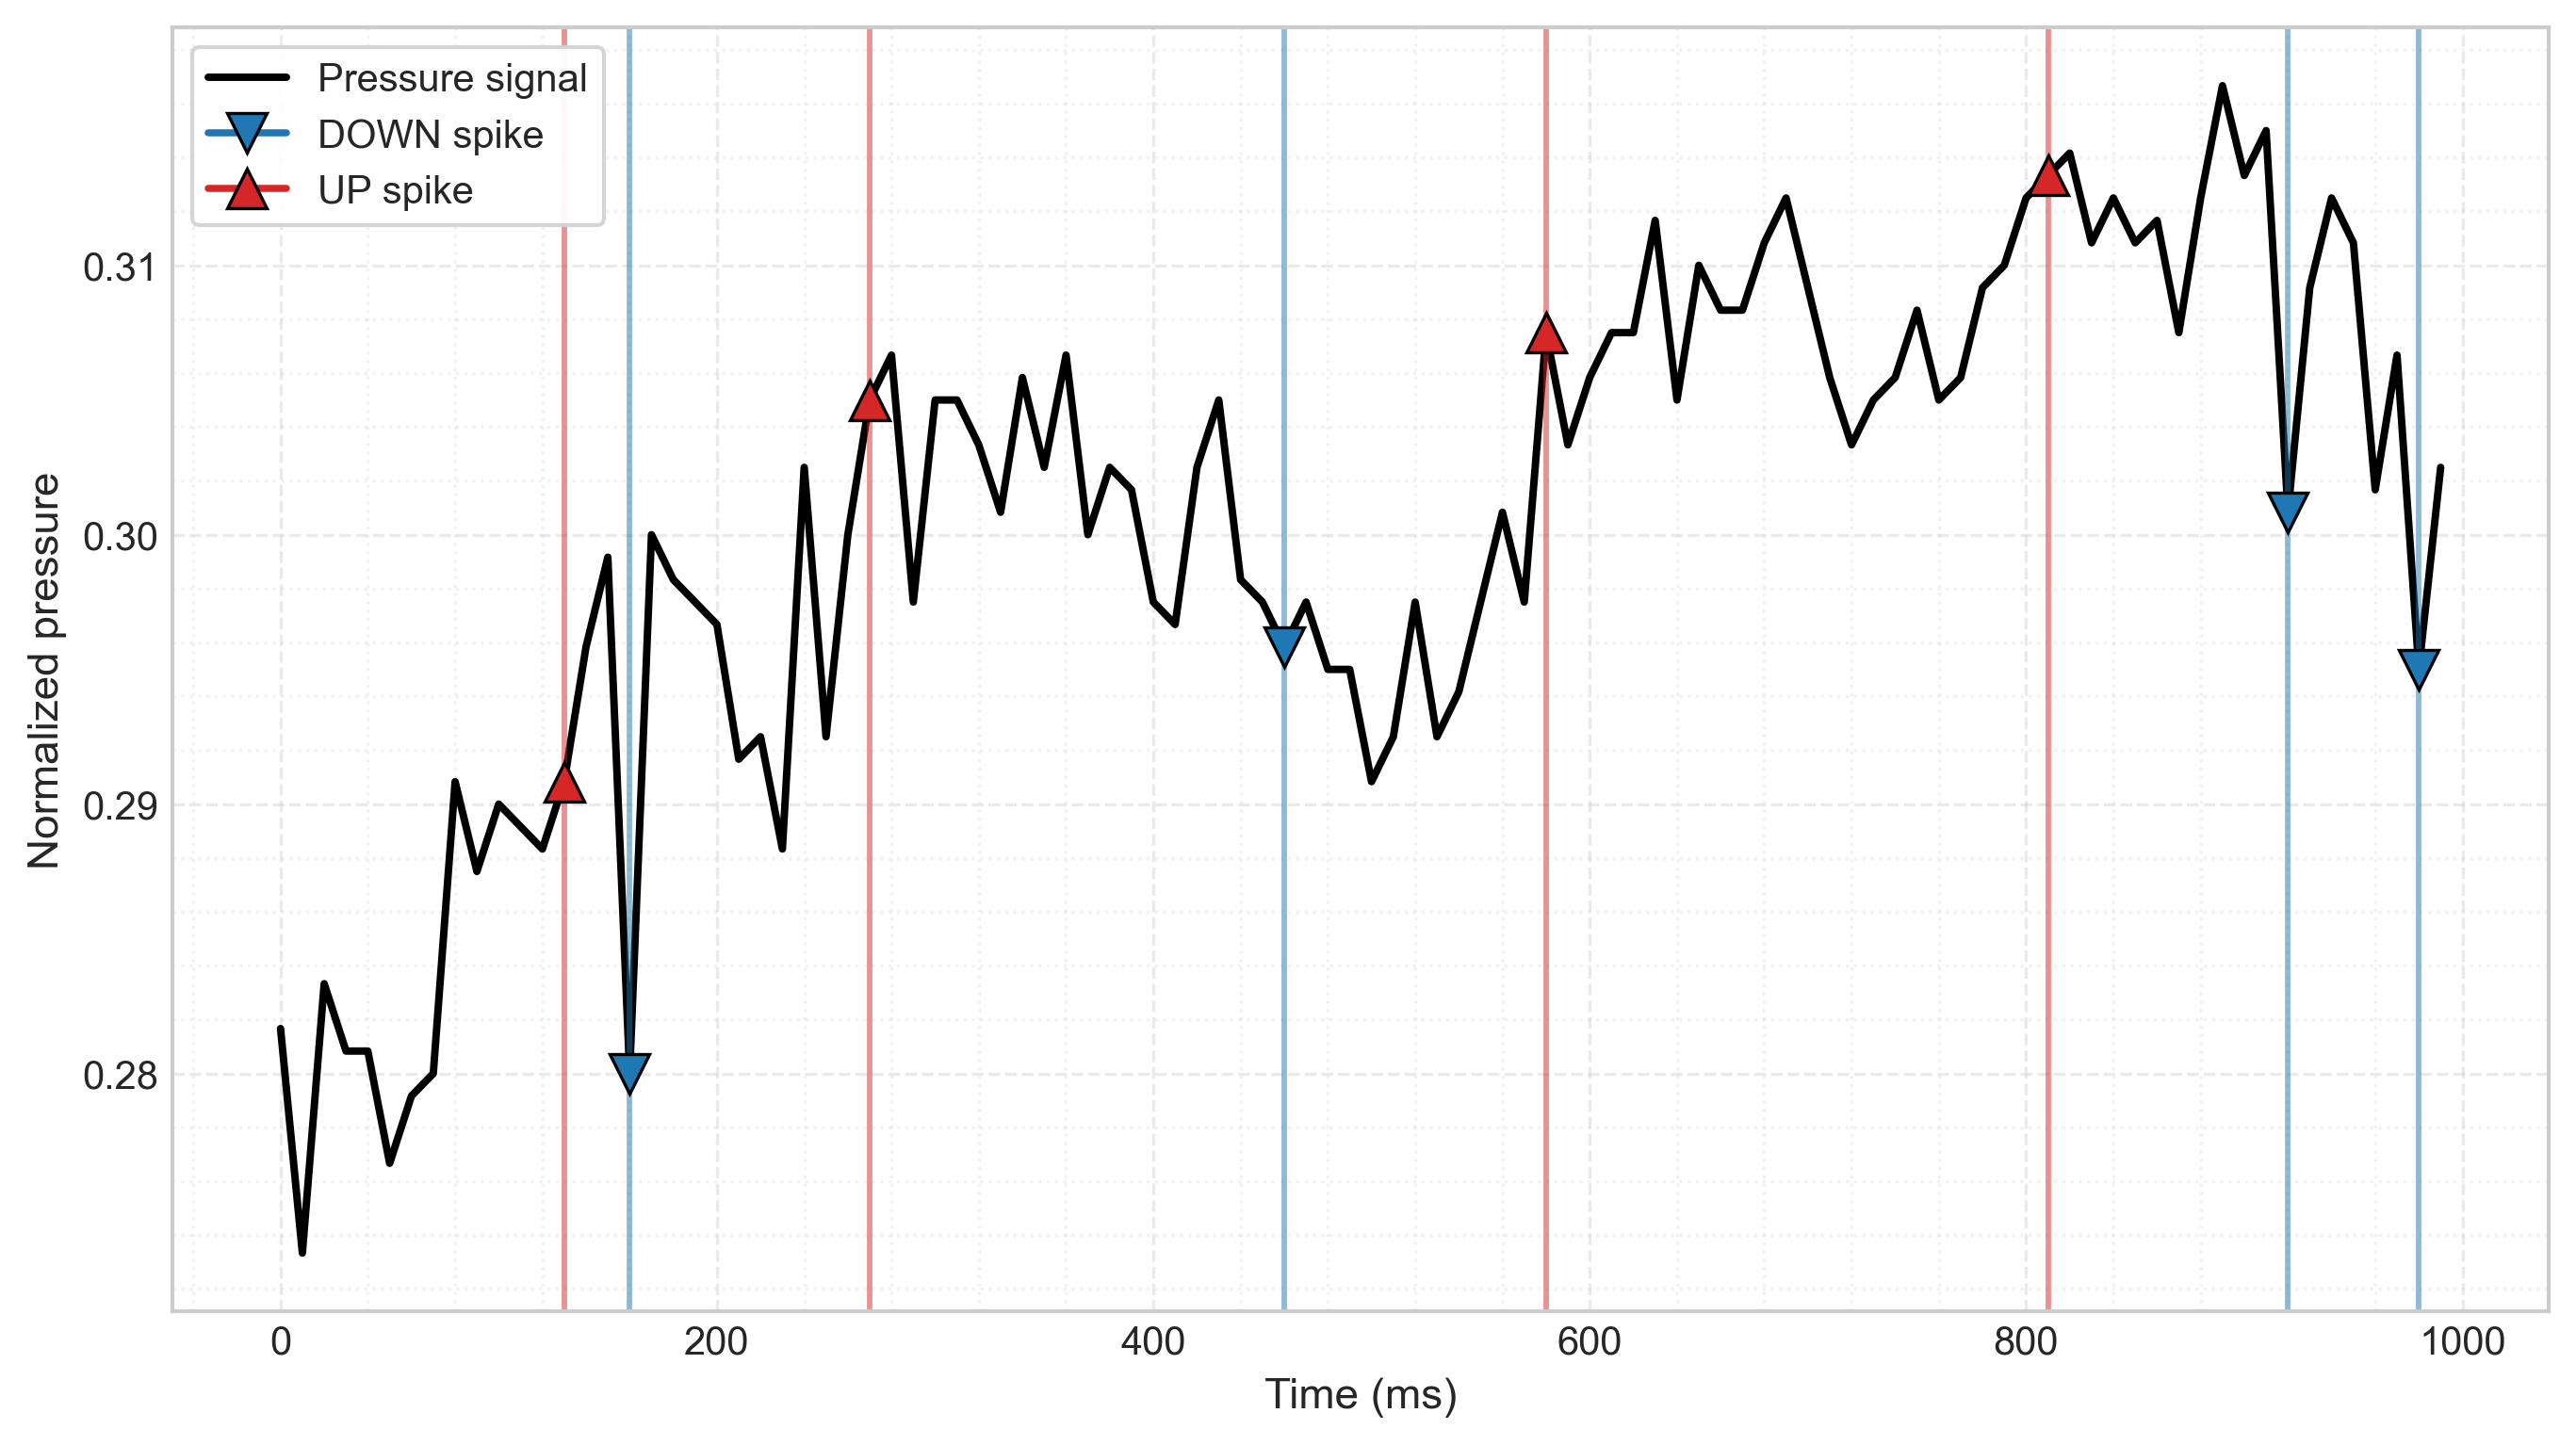

In [10]:
# Final version: top plot only, no title on axes (caption handles everything)

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# (Assume t_ms, pressure, spike_frames_up, spike_frames_dn,
#  THRESHOLD, TAXEL_IDX, NUM_FRAMES already defined)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'lines.linewidth': 1.8,
    'grid.alpha': 0.35,
})

fig = plt.figure(figsize=(9.0, 5.0), constrained_layout=True)
ax = fig.add_subplot(111)

ax.plot(t_ms, -pressure, color='black', lw=1.9, label='Pressure signal')
ax.set_xlabel('Time (ms)', fontsize=11)
ax.set_ylabel('Normalized pressure', fontsize=11)

ax.grid(True, which='major', linestyle='--', alpha=0.4)
ax.grid(True, which='minor', linestyle=':', alpha=0.25)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

# DOWN spikes
for i, f in enumerate(spike_frames_up):
    ax.axvline(t_ms[f], color='#1f77b4', alpha=0.5, ls='-', lw=1.4, zorder=2)
    ax.plot(t_ms[f], -pressure[f], marker='v', ms=10, color='#1f77b4', mec='k', mew=0.8, zorder=10,
            label='DOWN spike' if i == 0 else None)

# UP spikes
for i, f in enumerate(spike_frames_dn):
    ax.axvline(t_ms[f], color='#d62728', alpha=0.5, ls='-', lw=1.4, zorder=2)
    ax.plot(t_ms[f], -pressure[f], marker='^', ms=10, color='#d62728', mec='k', mew=0.8, zorder=10,
            label='UP spike' if i == 0 else None)

ax.legend(loc='best', frameon=True, edgecolor='lightgray', fancybox=True, framealpha=0.95)

plt.show()

# Export
fig.savefig('figures/adm_encoding_top_only.png', dpi=400, bbox_inches='tight', facecolor='white')
